simulação Monte Carlo condicional

In [2]:
import numpy as np
import pandas as pd

# ═══════════════════════════════════════════════════════════════
#  CONFIGURAÇÃO
# ═══════════════════════════════════════════════════════════════
N    = 1000
SEED = 42
rng  = np.random.default_rng(SEED)

# ═══════════════════════════════════════════════════════════════
#  1. FAIXA ETÁRIA
# ═══════════════════════════════════════════════════════════════
faixas       = ["Criança", "Jovem", "Adulto", "Senior"]
faixa_probs  = [0.10,       0.20,    0.50,     0.20   ]
faixa_etaria = rng.choice(faixas, size=N, p=faixa_probs)

# ═══════════════════════════════════════════════════════════════
#  2. SEXO
# ═══════════════════════════════════════════════════════════════
sexo = rng.choice(["Masculino", "Feminino"], size=N, p=[0.50, 0.50])

# ═══════════════════════════════════════════════════════════════
#  3. ESTADO CIVIL  (depende da Faixa Etária)
#     Regra-chave: Crianças só podem ser Solteiro.
#                  Jovens têm probabilidade quase nula de Viúvo.
# ═══════════════════════════════════════════════════════════════
estados = ["Solteiro", "Casado", "Divorciado", "Viúvo"]
estado_probs = {
    #              Solteiro  Casado  Divorciado  Viúvo
    "Criança": [  1.00,     0.00,   0.00,       0.00  ],
    "Jovem":   [  0.85,     0.14,   0.01,       0.00  ],
    "Adulto":  [  0.25,     0.55,   0.15,       0.05  ],
    "Senior":  [  0.10,     0.45,   0.20,       0.25  ],
}
estado_civil = np.array(
    [rng.choice(estados, p=estado_probs[f]) for f in faixa_etaria]
)

# ═══════════════════════════════════════════════════════════════
#  4. NÍVEL DE ATIVIDADE  (depende da Faixa Etária)
# ═══════════════════════════════════════════════════════════════
niveis      = ["Pouca", "Média", "Alta"]
nivel_probs = {
    #              Pouca  Média  Alta
    "Criança": [  0.50,  0.40,  0.10 ],
    "Jovem":   [  0.20,  0.45,  0.35 ],
    "Adulto":  [  0.30,  0.45,  0.25 ],
    "Senior":  [  0.50,  0.40,  0.10 ],
}
nivel_atividade = np.array(
    [rng.choice(niveis, p=nivel_probs[f]) for f in faixa_etaria]
)

# ═══════════════════════════════════════════════════════════════
#  5. CONTAGENS DE ATIVIDADES
#     Distribuição triangular (lo, moda, hi) por nível.
#     Moda assimétrica garante não-uniformidade e coerência.
# ═══════════════════════════════════════════════════════════════
#  Estrutura: { atividade: [(lo,moda,hi)_Pouca,
#                           (lo,moda,hi)_Média,
#                           (lo,moda,hi)_Alta] }
params = {
    #                   Pouca            Média             Alta
    "corridas":    [(0,  2,  6),   ( 5, 12, 22),   (20, 38, 65)],
    "caminhadas":  [(0,  3,  9),   ( 5, 12, 22),   (14, 26, 42)],
    "trilhos":     [(0,  1,  4),   ( 2,  5, 11),   ( 7, 15, 26)],
    "aulas_grupo": [(0,  4, 11),   ( 5, 16, 32),   (18, 45, 85)],
    "eventos":     [(0,  1,  3),   ( 1,  3,  6),   ( 3,  6, 12)],
}
nidx = {"Pouca": 0, "Média": 1, "Alta": 2}

def gerar_contagens(chave: str) -> np.ndarray:
    """Gera contagens inteiras via distribuição triangular por utilizador."""
    out = np.zeros(N, dtype=int)
    for i, nivel in enumerate(nivel_atividade):
        lo, moda, hi = params[chave][nidx[nivel]]
        val = rng.triangular(lo, moda, hi + 0.9999)
        out[i] = int(val)
    return out

corridas    = gerar_contagens("corridas")
caminhadas  = gerar_contagens("caminhadas")
trilhos     = gerar_contagens("trilhos")
aulas_grupo = gerar_contagens("aulas_grupo")
eventos     = gerar_contagens("eventos")

# ═══════════════════════════════════════════════════════════════
#  6. KM PERCORRIDOS
#     Fórmula: corridas × km/corrida + caminhadas × km/caminhada
#              + trilhos × km/trilho
#     Distâncias médias típicas com variação individual (ruído).
# ═══════════════════════════════════════════════════════════════
km_por_corrida   = rng.uniform(4.5,  9.0,  N)   # corrida média: ~5–9 km
km_por_caminhada = rng.uniform(2.5,  5.5,  N)   # caminhada: ~3–5 km
km_por_trilho    = rng.uniform(7.0, 16.0,  N)   # trilho: ~7–16 km

km_total = (
    corridas   * km_por_corrida   +
    caminhadas * km_por_caminhada +
    trilhos    * km_por_trilho
).round(1)

# ═══════════════════════════════════════════════════════════════
#  7. PASSAPORTE  (soma exata das 5 atividades — nunca aleatório)
# ═══════════════════════════════════════════════════════════════
passaporte = corridas + caminhadas + trilhos + aulas_grupo + eventos

# ═══════════════════════════════════════════════════════════════
#  8. DATAFRAME FINAL
# ═══════════════════════════════════════════════════════════════
df = pd.DataFrame({
    "Faixa Etária":            faixa_etaria,
    "Sexo":                    sexo,
    "Estado Civil":            estado_civil,
    "Nível de Atividade":      nivel_atividade,
    "Nº Corridas":             corridas,
    "Km Percorridos":          km_total,
    "Nº Caminhadas":           caminhadas,
    "Nº Trilhos da Natureza":  trilhos,
    "Nº Aulas de Grupo":       aulas_grupo,
    "Nº Eventos Especiais":    eventos,
    "Passaporte":              passaporte,
})

# ═══════════════════════════════════════════════════════════════
#  9. VALIDAÇÕES AUTOMÁTICAS
# ═══════════════════════════════════════════════════════════════
atividades_cols = [
    "Nº Corridas", "Nº Caminhadas", "Nº Trilhos da Natureza",
    "Nº Aulas de Grupo", "Nº Eventos Especiais"
]
erros = []

# V1 — Passaporte = soma exata das 5 atividades
passaporte_calculado = df[atividades_cols].sum(axis=1)
if not (df["Passaporte"] == passaporte_calculado).all():
    erros.append("ERRO V1: Passaporte não coincide com a soma das atividades.")

# V2 — Crianças só podem ser Solteiro
criancas_invalidas = df[df["Faixa Etária"] == "Criança"]["Estado Civil"].isin(
    ["Casado", "Divorciado", "Viúvo"]
).sum()
if criancas_invalidas > 0:
    erros.append(f"ERRO V2: {criancas_invalidas} crianças com estado civil inválido.")

# V3 — Sem Km negativos
if (df["Km Percorridos"] < 0).any():
    erros.append("ERRO V3: Existem valores negativos em Km Percorridos.")

# V4 — Sem contagens negativas
for col in atividades_cols + ["Passaporte"]:
    if (df[col] < 0).any():
        erros.append(f"ERRO V4: Valores negativos em '{col}'.")

# V5 — Número correto de registos
if len(df) != N:
    erros.append(f"ERRO V5: Esperados {N} registos, encontrados {len(df)}.")

if erros:
    for e in erros:
        print(e)
    raise ValueError("Validação falhou. Corrige os erros acima.")
else:
    print("✓ Todas as validações passaram com sucesso.\n")

# ═══════════════════════════════════════════════════════════════
#  10. EXPORTAÇÃO
# ═══════════════════════════════════════════════════════════════
output_path = "clientes_simulados.xlsx"
df.to_excel(output_path, index=False)
print(f"✓ Ficheiro exportado: {output_path}\n")

# ═══════════════════════════════════════════════════════════════
#  11. AMOSTRA — head()
# ═══════════════════════════════════════════════════════════════
print("─" * 60)
print("PRIMEIRAS 5 LINHAS")
print("─" * 60)
print(df.head().to_string(index=True))

# ═══════════════════════════════════════════════════════════════
#  12. TABELA RESUMO por Faixa Etária e Nível de Atividade
# ═══════════════════════════════════════════════════════════════
print("\n" + "─" * 60)
print("RESUMO POR FAIXA ETÁRIA × NÍVEL DE ATIVIDADE")
print("─" * 60)

resumo = (
    df.groupby(["Faixa Etária", "Nível de Atividade"], observed=True)
    .agg(
        Utilizadores       = ("Passaporte",          "count"),
        Corridas_média     = ("Nº Corridas",          "mean"),
        Caminhadas_média   = ("Nº Caminhadas",        "mean"),
        Trilhos_média      = ("Nº Trilhos da Natureza","mean"),
        Aulas_média        = ("Nº Aulas de Grupo",    "mean"),
        Eventos_média      = ("Nº Eventos Especiais", "mean"),
        Km_média           = ("Km Percorridos",       "mean"),
        Passaporte_médio   = ("Passaporte",           "mean"),
    )
    .round(1)
)

# Ordenar faixas etárias de forma lógica
ordem_faixas = ["Criança", "Jovem", "Adulto", "Senior"]
ordem_niveis = ["Pouca", "Média", "Alta"]
resumo = resumo.reindex(
    pd.MultiIndex.from_product([ordem_faixas, ordem_niveis],
                               names=["Faixa Etária", "Nível de Atividade"]),
    fill_value=0
)
print(resumo.to_string())
print()

✓ Todas as validações passaram com sucesso.

✓ Ficheiro exportado: clientes_simulados.xlsx

────────────────────────────────────────────────────────────
PRIMEIRAS 5 LINHAS
────────────────────────────────────────────────────────────
  Faixa Etária       Sexo Estado Civil Nível de Atividade  Nº Corridas  Km Percorridos  Nº Caminhadas  Nº Trilhos da Natureza  Nº Aulas de Grupo  Nº Eventos Especiais  Passaporte
0       Adulto  Masculino   Divorciado               Alta           46           703.8             22                      15                 59                     7         149
1       Adulto  Masculino       Casado              Média           11           148.7             14                       3                 26                     5          59
2       Senior  Masculino        Viúvo              Pouca            4            72.2              5                       2                  5                     1          17
3       Adulto  Masculino       Casado             

In [3]:
df.describe()

,Nº Corridas,Km Percorridos,Nº Caminhadas,Nº Trilhos da Natureza,Nº Aulas de Grupo,Nº Eventos Especiais,Passaporte
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,14.962000,224.015600,12.681000,6.427000,19.965000,3.305000,57.34000
std,14.557145,190.353663,9.180279,5.730751,17.942902,2.495236,46.66828
min,0.000000,12.200000,0.000000,0.000000,0.000000,0.000000,5.00000
25%,3.000000,57.525000,5.000000,2.000000,6.000000,1.000000,16.00000
50%,11.000000,187.800000,11.500000,5.000000,15.000000,3.000000,49.00000
75%,18.000000,275.475000,18.000000,9.000000,26.000000,5.000000,64.00000
max,64.000000,848.300000,42.000000,25.000000,81.000000,12.000000,190.00000


c:\Users\adfma\anaconda3\envs\fall2526\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


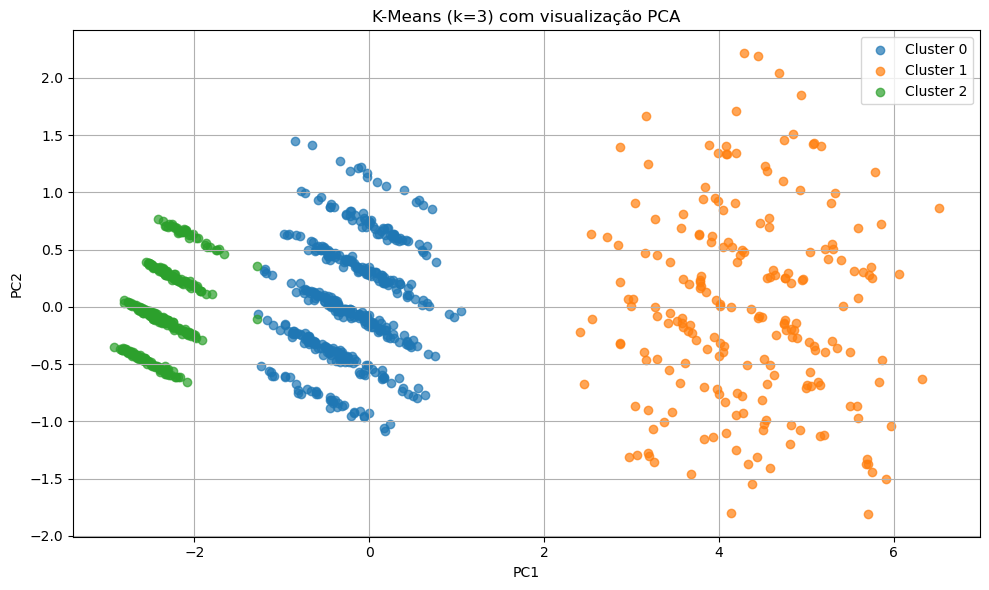

In [4]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

cluster_features = [
    "Nº Corridas",
    "Km Percorridos",
    "Nº Caminhadas",
    "Nº Trilhos da Natureza",
    "Nº Aulas de Grupo",
    "Nº Eventos Especiais",
    "Passaporte"
]

X = df[cluster_features].copy()

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
df["Cluster"] = kmeans.fit_predict(X_scaled)

# PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df["PC1"] = X_pca[:, 0]
df["PC2"] = X_pca[:, 1]

# Gráfico
plt.figure(figsize=(10, 6))

for cluster_id in sorted(df["Cluster"].unique()):
    mask = df["Cluster"] == cluster_id
    plt.scatter(
        df.loc[mask, "PC1"],
        df.loc[mask, "PC2"],
        label=f"Cluster {cluster_id}",
        alpha=0.7
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means (k=3) com visualização PCA")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

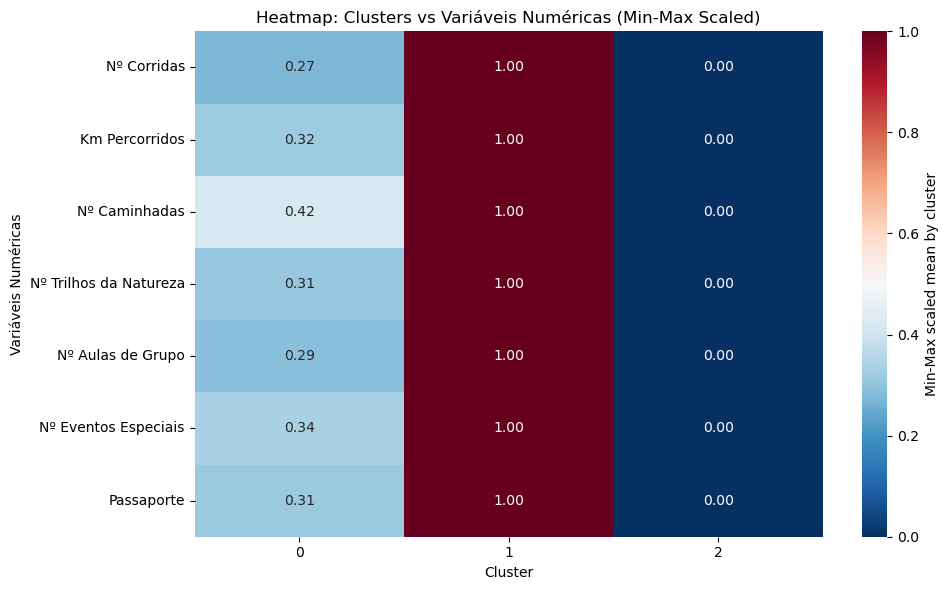

In [6]:
import seaborn as sns
# Coluna de cluster
cluster_col = "Cluster"

# Variáveis numéricas a incluir no profiling
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Remover colunas que não devem entrar no heatmap
exclude_numeric = [cluster_col, "PC1", "PC2"]
numeric_cols = [c for c in numeric_cols if c not in exclude_numeric and c in df.columns]

# Médias por cluster
cluster_means = df.groupby(cluster_col)[numeric_cols].mean()

# Min-Max scaling entre clusters, variável a variável
denominator = cluster_means.max() - cluster_means.min()
denominator = denominator.replace(0, 1)  # evita divisão por zero

cluster_means_minmax = (cluster_means - cluster_means.min()) / denominator

# Heatmap
plt.figure(figsize=(10, max(6, len(numeric_cols) * 0.5)))
sns.heatmap(
    cluster_means_minmax.T,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0.5,
    cbar_kws={"label": "Min-Max scaled mean by cluster"}
)

plt.title("Heatmap: Clusters vs Variáveis Numéricas (Min-Max Scaled)")
plt.xlabel("Cluster")
plt.ylabel("Variáveis Numéricas")
plt.tight_layout()
plt.show()

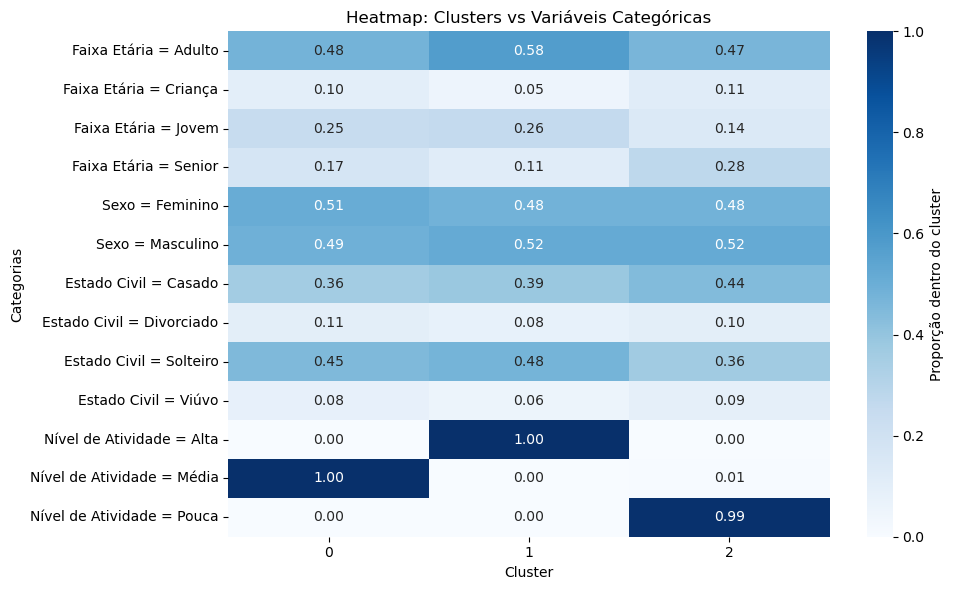

In [7]:
# Coluna de cluster
cluster_col = "Cluster"

# Variáveis categóricas
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

# Garantir que a coluna de cluster não entra, caso exista como categórica
categorical_cols = [c for c in categorical_cols if c != cluster_col]

# Construir tabela para heatmap
cat_heatmap_parts = []

for col in categorical_cols:
    # Proporção de cada categoria dentro de cada cluster
    temp = pd.crosstab(df[cluster_col], df[col], normalize="index")
    
    # Renomear colunas para identificar variável + categoria
    temp.columns = [f"{col} = {cat}" for cat in temp.columns]
    
    # Transpor para ficar categorias nas linhas e clusters nas colunas
    cat_heatmap_parts.append(temp.T)

# Juntar tudo
cat_heatmap = pd.concat(cat_heatmap_parts, axis=0)

# Heatmap
plt.figure(figsize=(10, max(6, len(cat_heatmap) * 0.45)))
sns.heatmap(
    cat_heatmap,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    cbar_kws={"label": "Proporção dentro do cluster"}
)

plt.title("Heatmap: Clusters vs Variáveis Categóricas")
plt.xlabel("Cluster")
plt.ylabel("Categorias")
plt.tight_layout()
plt.show()